<a href="https://colab.research.google.com/github/angel-myr/prediccion_clientes/blob/main/exploracion_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Análisis exploratorio

## Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Telco-Customer-Churn.csv')

## Revisión de Estructura

In [ ]:
# Dimensiones
df.shape

(7043, 21)

In [ ]:
# Primeras filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Tipos de datos y nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Estadísticos básicos
df.describe(
    include='all'
)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## Calidad de Datos

In [ ]:
# Nulos por columna
nulos = df.isnull().sum()
nulos.tolist()

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
# Duplicados
dup = df.duplicated().sum()
dup.tolist()

0

In [ ]:
# Valores únicos por columna
df.nunique().sort_values()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3


## Limpieza y Transformación

In [ ]:
# Antes
df.shape

(7043, 21)

In [ ]:
# Eliminar duplicados
df.drop_duplicates()
df.shape

(7043, 21)

In [ ]:
# Cambiar nulos numéricos (con mediana)
# df['col_num'].fillna(df['col_num'].median(), inplace=True)

# Imputar nulos categóricos ('Desconocido')
# df['col_cat'].fillna('Desconocido', inplace=True)

# Corregir tipos de datos
# df['col_fecha'] = pd.to_datetime(df['col_fecha'])
# df['col_valor'] = pd.to_numeric(df['col_valor'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Eliminar columna
# df.drop(columns=['col_inutil'], inplace=True)

## Análisis univariado

#### Variables numéricas

In [ ]:
# Columnas numéricas
numericos = df.select_dtypes(include=np.number).columns.tolist()
numericos

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

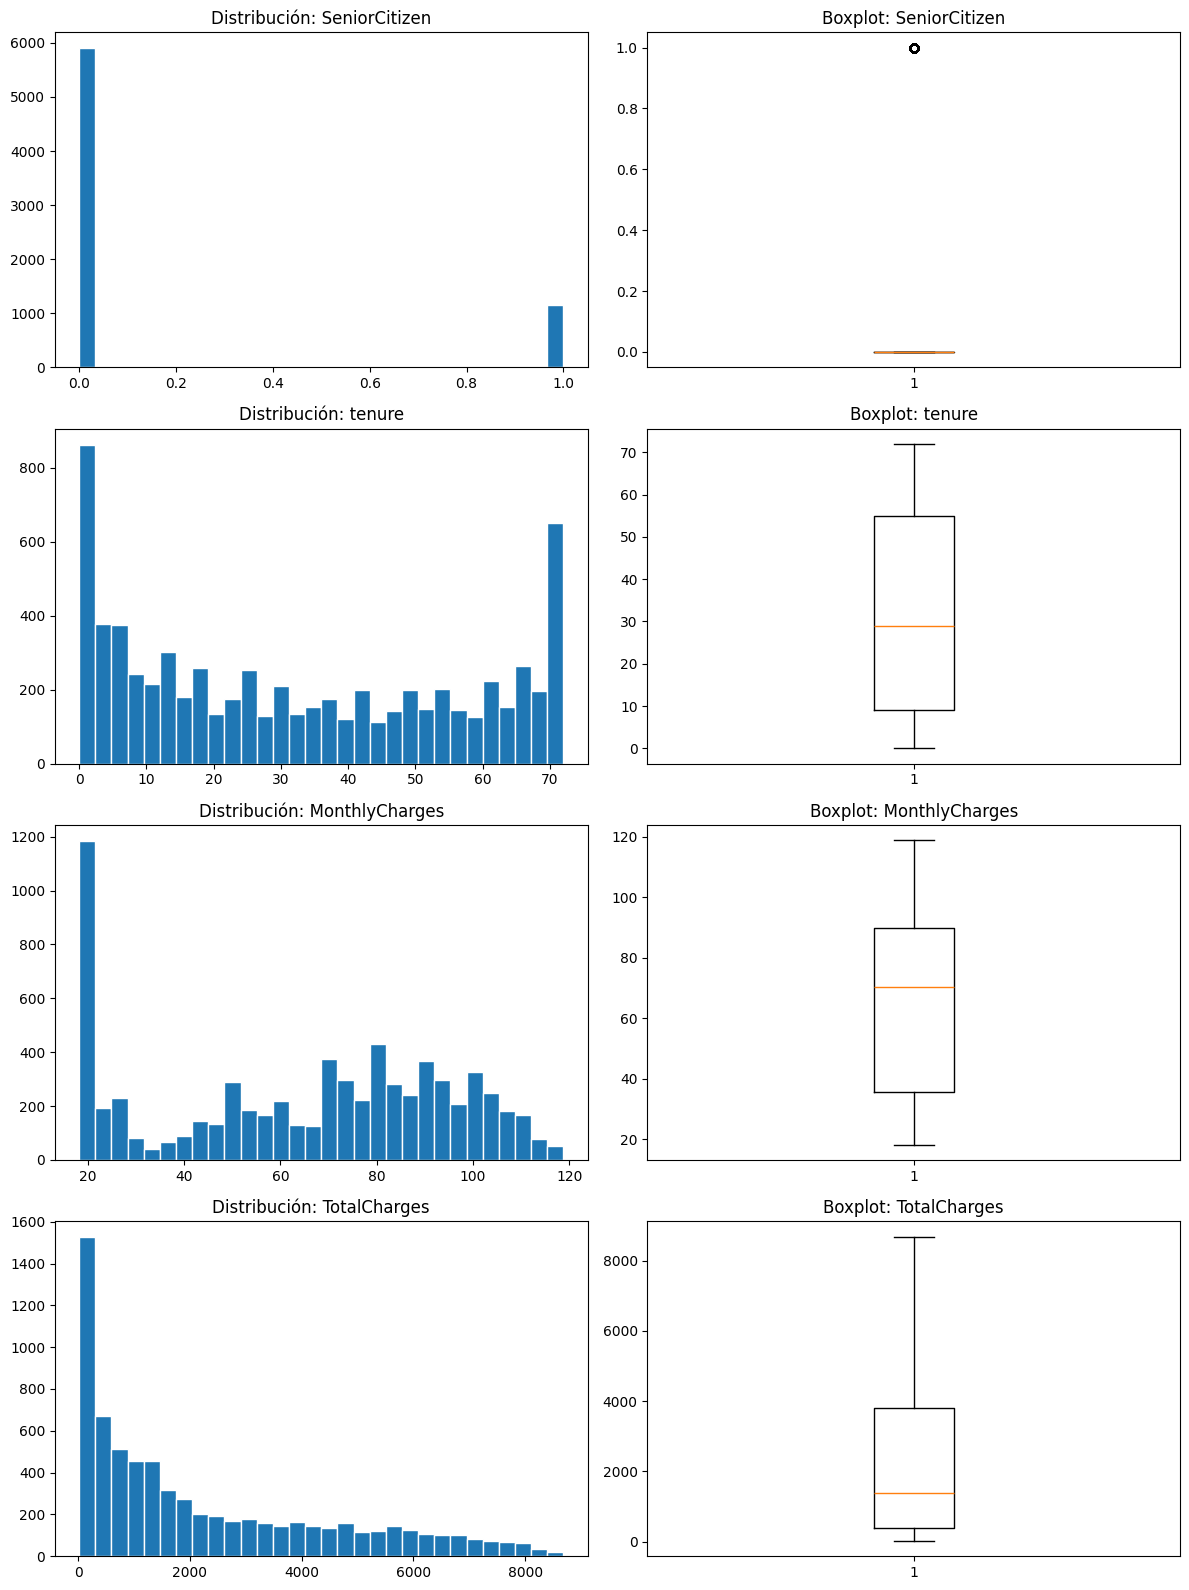

In [ ]:
fig, axes = plt.subplots(len(numericos), 2, figsize=(12, 4 * len(numericos)))

# Gráficas
for i, col in enumerate(numericos):
    # Histograma
    axes[i, 0].hist(df[col].dropna(), bins=30, edgecolor='white')
    axes[i, 0].set_title(f'Distribución: {col}')
    # Boxplot (detecta outliers)
    axes[i, 1].boxplot(df[col].dropna())
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

#### Variables Categóricas

In [ ]:
# Columnas Categóricas
categoricas = df.select_dtypes(include='object').columns.tolist()
categoricas.remove('customerID')
categoricas

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

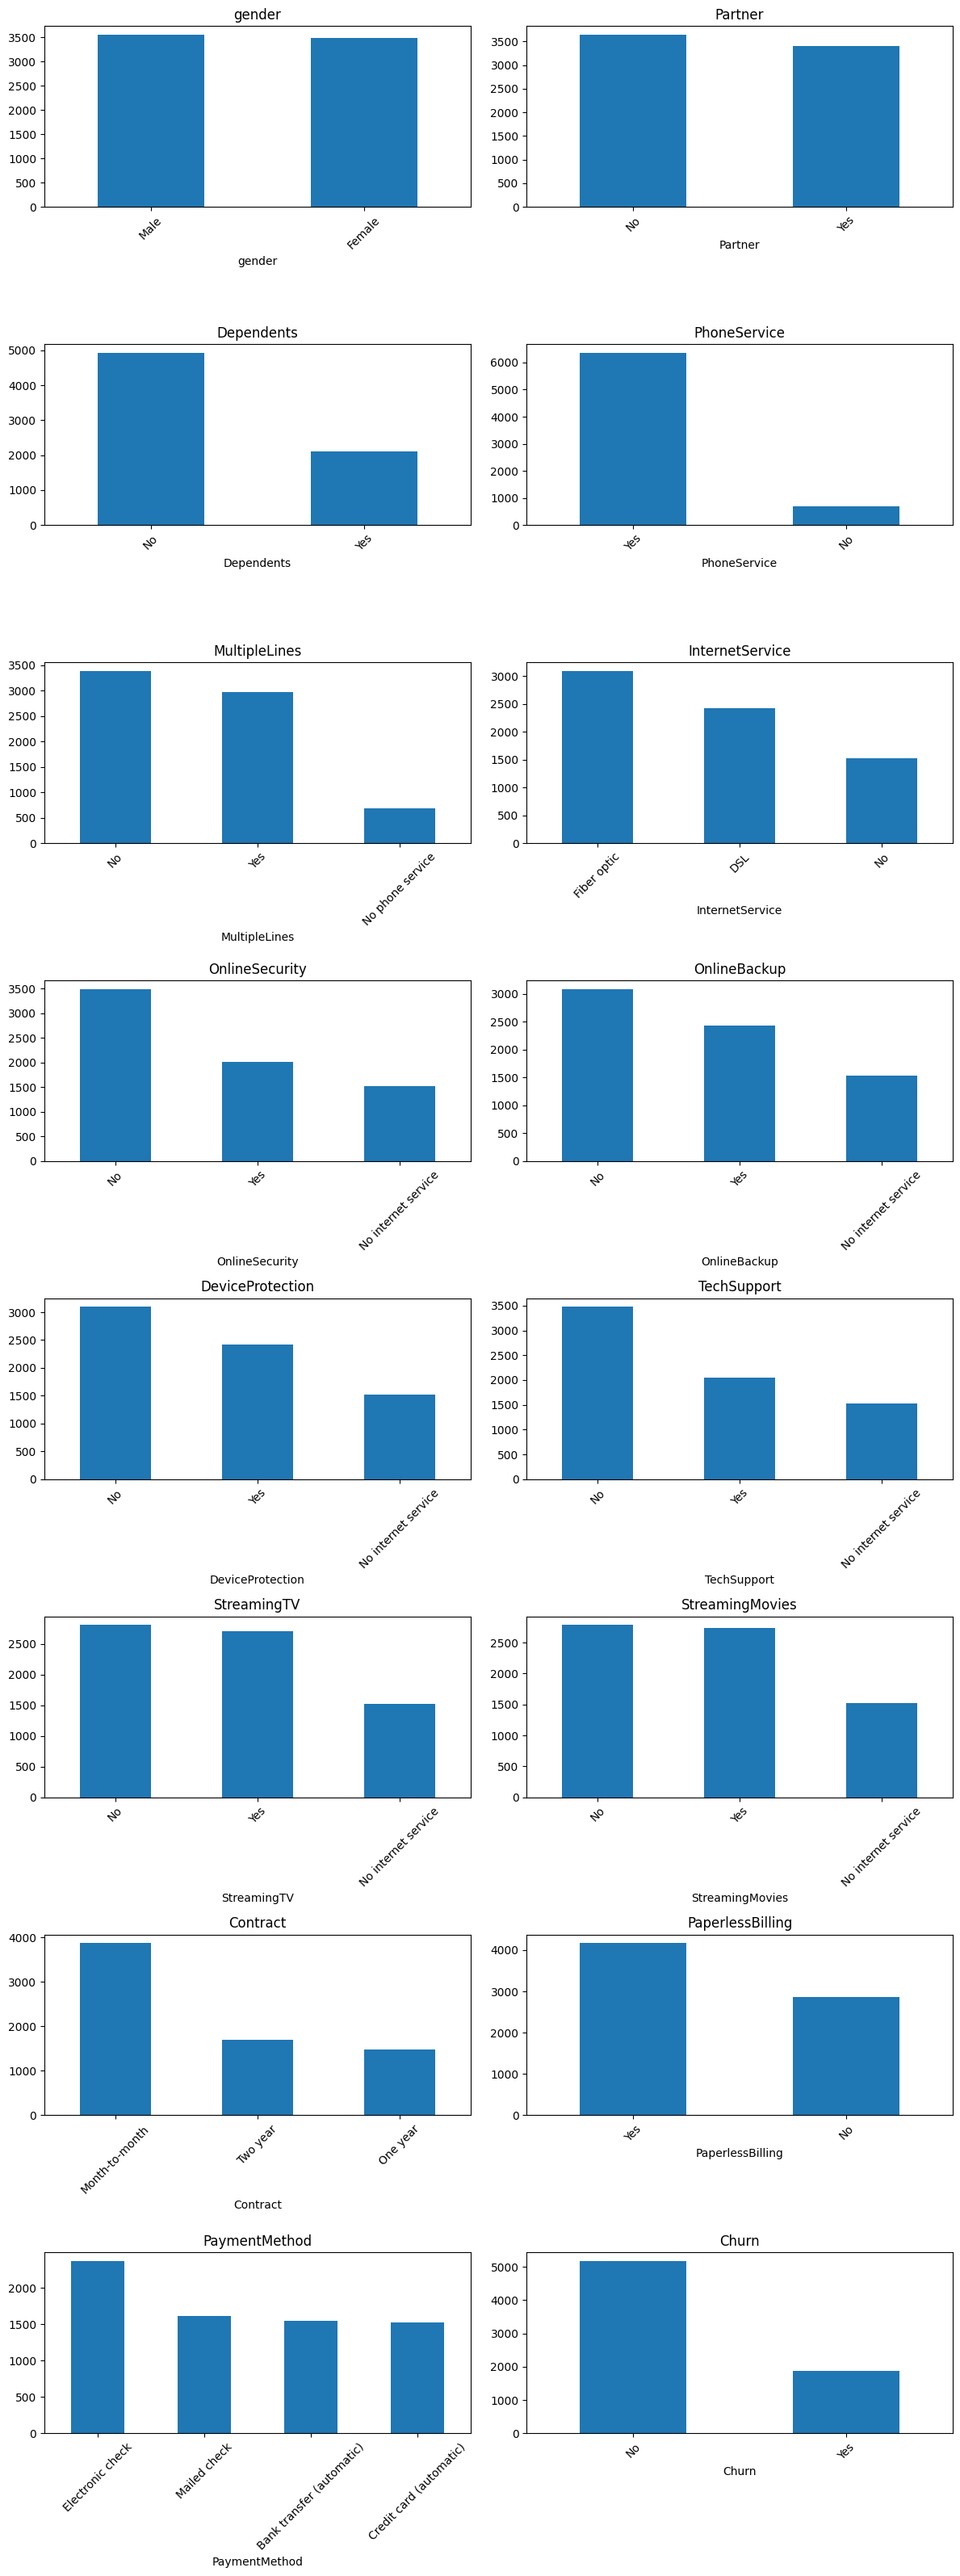

In [ ]:
fig, axes = plt.subplots(
    nrows=int(np.ceil(len(categoricas) / 2)),
    ncols=2,
    figsize=(12, 4 * int(np.ceil(len(categoricas) / 2)))
)

axes = axes.flatten()

# Gráficas
for i, col in enumerate(categoricas):
    # Solo histograma
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Análisis multivariado

In [ ]:
# Matriz de correlaciones
corr = df[numericos].corr()
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


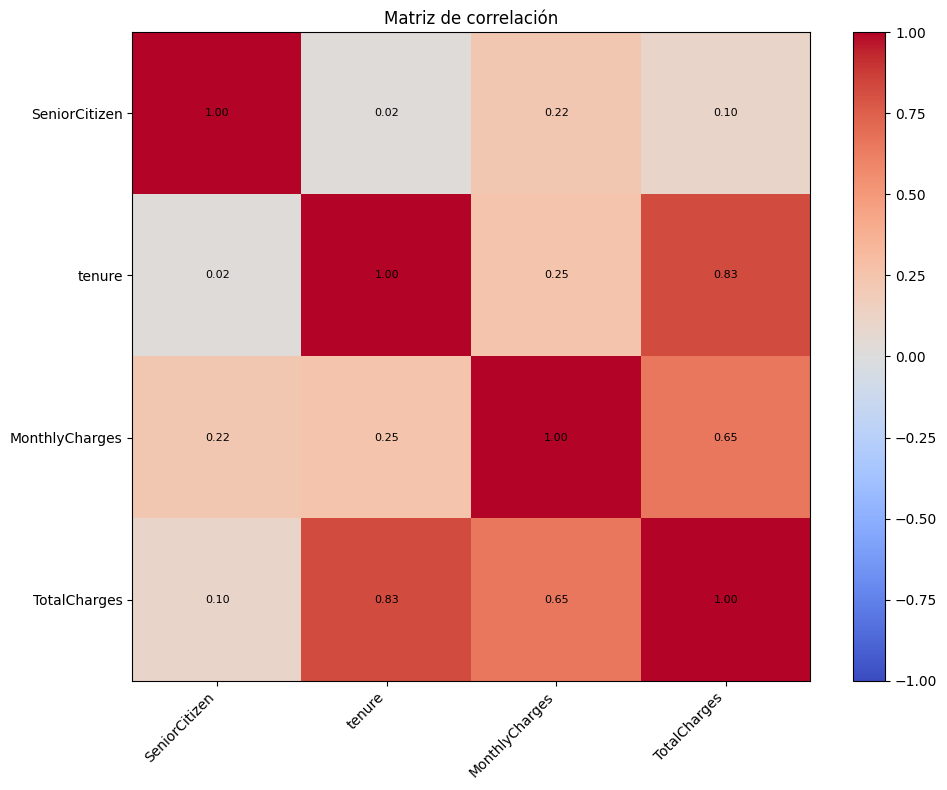

In [ ]:
# Gráficas
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr)), corr.columns)

# Con valores
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## Conclusiones por responder

1. Dimensiones finales del dataset tras la limpieza
2. Variables con más nulos y cómo las trataste
3. Distribuciones relevantes (columnas sesgadas, outliers importantes)
4. Correlaciones fuertes (positivas y negativas) con la variable objetivo
5. Categorías desbalanceadas que podrían afectar un modelo
6. Hipótesis generadas para la siguiente etapa de modelado
7. Features candidatos más prometedores

